# Tester_branch에서 최종 모델 성능 확인 진행

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt

wine = load_wine()

# feature로 사용할 데이터에서는 'target' 컬럼을 drop합니다.
# target은 'target' 컬럼만을 대상으로 합니다.
# X, y 데이터를 test size는 0.2, random_state 값은 42로 하여 train 데이터와 test 데이터로 분할합니다.


df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target

X = df.drop(columns='target') 
y = df['target']  

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# DT 모델링 성능

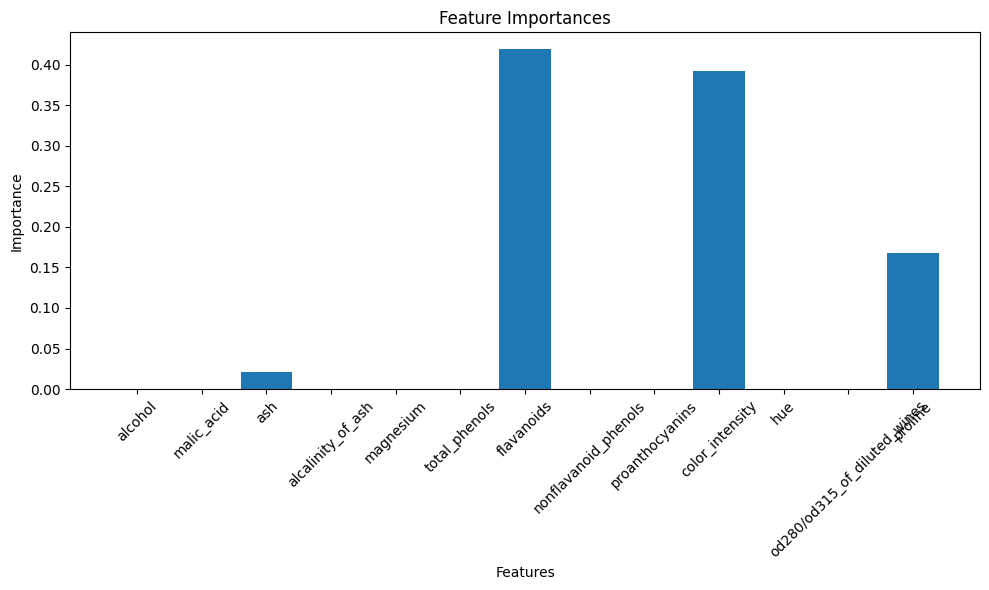

In [2]:
dt = DecisionTreeClassifier(random_state=42)

dt_param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 3, 4, 5],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

dt_grid_search = GridSearchCV(
    estimator=dt,
    param_grid=dt_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

dt_grid_search.fit(X_train, y_train)

dt_best_model = dt_grid_search.best_estimator_
dt_y_pred = dt_best_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, dt_y_pred)

dt_importances = dt_best_model.feature_importances_
dt_feature_names = X.columns

plt.figure(figsize=(10, 6))
plt.title("Feature Importances")

plt.bar(range(X.shape[1]), dt_importances, align='center')
plt.xticks(range(X.shape[1]), dt_feature_names,  rotation=45)

plt.xlabel("Features")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

<img src="../참고이미지/Git/DT_Modeling.png" width="80%">

# XGB 모델링 성능

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Test Accuracy: 0.9722222222222222


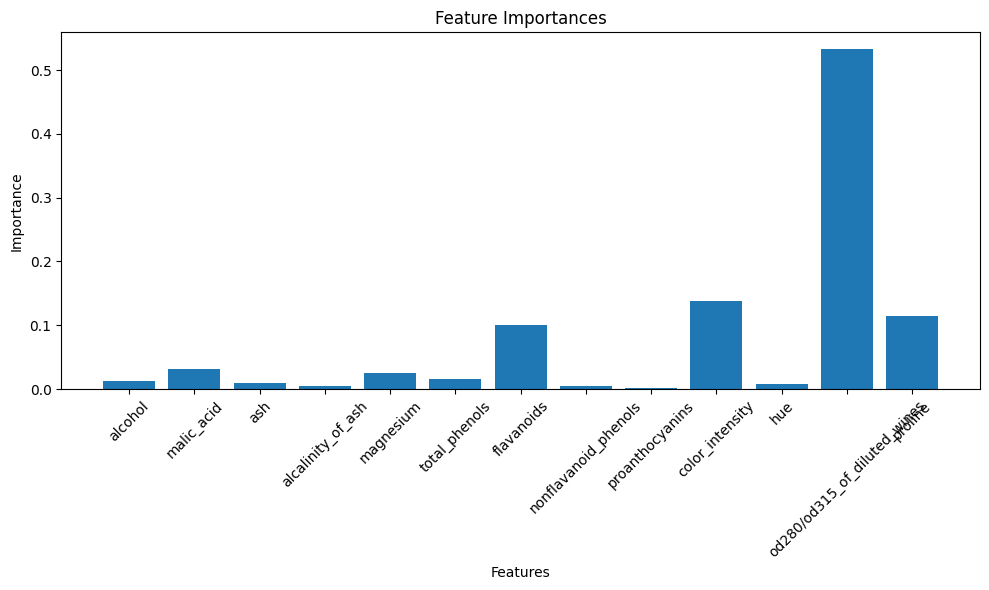

In [3]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

xgb = XGBClassifier(random_state=42, eval_metric='mlogloss')

xgb_param_grid = {
    'max_depth': [3, 5, 7, 9, 15],
    'learning_rate': [0.1, 0.01, 0.001],
    'n_estimators': [50, 100, 200, 300]
}

xgb_grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=xgb_param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1,
    verbose=1
)

xgb_grid_search.fit(X_train, y_train)

xgb_best_model = xgb_grid_search.best_estimator_
xgb_y_pred = xgb_best_model.predict(X_test)
xgb_accuracy = accuracy_score(y_test, xgb_y_pred)

print("Best Parameters:", xgb_grid_search.best_params_)
print("Test Accuracy:", xgb_accuracy)

xgb_importances = xgb_best_model.feature_importances_
xgb_feature_names = X.columns

plt.figure(figsize=(10, 6))
plt.title("Feature Importances")

plt.bar(range(X.shape[1]), xgb_importances, align='center')
plt.xticks(range(X.shape[1]), xgb_feature_names, rotation=45)

plt.xlabel("Features")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

<img src="../참고이미지/Git/XGB_Modeling.png" width="80%">`

# 성능 비교 시각화

==================== DT 성능 확인 ====================
DT accuracy : 0.9444444444444444
              precision    recall  f1-score   support

           0       1.00      0.93      0.96        14
           1       0.88      1.00      0.93        14
           2       1.00      0.88      0.93         8

    accuracy                           0.94        36
   macro avg       0.96      0.93      0.94        36
weighted avg       0.95      0.94      0.94        36


==================== XGB 성능 확인 ====================
XGB accuracy : 0.9722222222222222
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       0.93      1.00      0.97        14
           2       1.00      0.88      0.93         8

    accuracy                           0.97        36
   macro avg       0.98      0.96      0.97        36
weighted avg       0.97      0.97      0.97        36



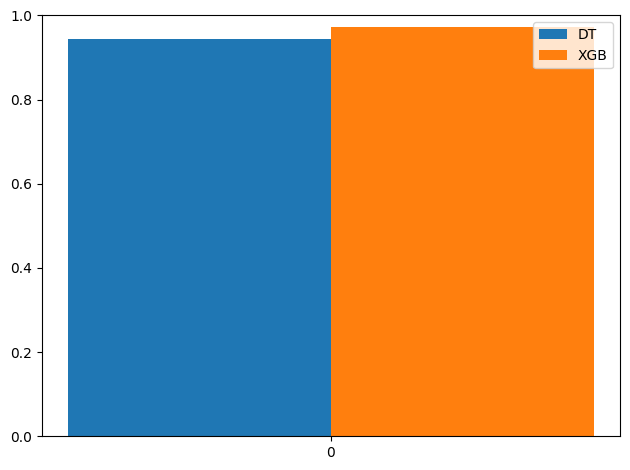

In [7]:
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

print("="*20, "DT 성능 확인", "="*20)
dt_accuracy = accuracy_score(y_test, dt_y_pred)
print(f"DT accuracy : {dt_accuracy}")
print(classification_report(y_test, dt_y_pred))

print("\n" + "="*20, "XGB 성능 확인", "="*20)
xgb_accuracy = accuracy_score(y_test, xgb_y_pred)
print(f"XGB accuracy : {xgb_accuracy}")
print(classification_report(y_test, xgb_y_pred))

bar_width = 0.35
x = [0]

plt.bar(x[0] - bar_width/2, dt_accuracy, width=bar_width, label='DT')
plt.bar(x[0] + bar_width/2, xgb_accuracy, width=bar_width, label='XGB')

plt.xticks([0])
plt.ylim(0, 1.0)
plt.legend()

plt.grid(False)

plt.tight_layout()
plt.show()

<img src="../참고이미지/Git/성능_비교_시각화.png" width="40%">